# Практичне завдання 1 — Автономна агентна система «SRE-асистент з управління інцидентами»
**Моісеєнко Світлана** · курс «Проєктування автономних агентів»

## Мета
Самостійно реалізувати повний цикл побудови автономного LLM-агента для нової предметної області —
**управління ІТ-інцидентами (SRE / on-call)**. Агент допомагає черговому інженеру: перевіряє стан
сервісів, аналізує логи, рахує SLA та бюджет помилок, шукає runbook-и у базі знань і — після
підтвердження людиною — перезапускає сервіс.

## Що реалізовано
| Компонент | Реалізація |
|---|---|
| 5 інструментів з Pydantic v2 | `search_runbooks` (RAG), `get_service_status`, `query_logs`, `calculate_sla`, `restart_service` (ризиковий) |
| ReAct-агент у LangGraph | цикл `agent → tools → agent`, guardrails `max_steps=10`, `timeout=120 с`, детекція повторів, JSON-лог траєкторії |
| Plan-and-Execute | `planner → executor (вкладений ReAct) → replanner`, structured outputs `Plan` та `ReplanDecision` |
| Checkpointer | `SqliteSaver` (файл), пам'ять між запитами, відновлення після «збою», `get_state()` |
| Agentic RAG | ChromaDB, 10 runbook-документів, агент сам вирішує, коли шукати |
| Human-in-the-Loop | `interrupt_before=["risky_tools"]`, демо approve та reject |
| Тести | pytest: 9 тестів схем + 7 тестів інструментів + 3 тести ReAct-циклу |
| Бонуси | порівняння ReAct vs Plan-and-Execute, Mermaid-візуалізація графів, fallback-стратегія інструментів |

## Секція 0. Встановлення залежностей
Клітинка ідемпотентна: у Colab доставляє відсутні пакети, локально — нічого не робить.

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "langgraph": "langgraph",
    "langgraph.checkpoint.sqlite": "langgraph-checkpoint-sqlite",
    "langchain_core": "langchain-core",
    "langchain_openai": "langchain-openai",
    "chromadb": "chromadb",
    "pydantic": "pydantic>=2",
    "pytest": "pytest",
    "matplotlib": "matplotlib",
}

missing = [pkg for module, pkg in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    print(f"Встановлюю: {', '.join(missing)}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
print("Усі залежності доступні")

Усі залежності доступні


## Секція 1. Імпорти та конфігурація
`AgentConfig` — єдине джерело правди для захисних механізмів ReAct-агента (`max_steps=10`,
`timeout_s=120`, детекція повторних викликів) та лімітів Plan-and-Execute.

In [2]:
import hashlib
import json
import math
import operator
import os
import re
import sqlite3
import sys
import time
from pathlib import Path
from typing import Annotated, Any, Literal, TypedDict

from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import AIMessage, AnyMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.outputs import ChatGeneration, ChatResult
from langchain_core.tools import BaseTool, tool
from langchain_core.utils.function_calling import convert_to_openai_tool
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field, ValidationInfo, field_validator

OUTPUT_DIR = Path.cwd()
TRAJECTORY_PATH = OUTPUT_DIR / "trajectory.json"
CHECKPOINT_DB = OUTPUT_DIR / "checkpoints.sqlite"


class AgentConfig(BaseModel):
    """Налаштування агента та його захисних механізмів."""

    max_steps: int = Field(default=10, ge=1, le=50, description="Максимум ітерацій циклу LLM→tools")
    timeout_s: float = Field(default=120.0, gt=0, description="Загальний тайм-аут виконання, секунд")
    detect_loops: bool = Field(default=True, description="Зупиняти при повторному ідентичному tool call")
    max_plan_steps: int = Field(default=8, ge=1, le=20, description="Максимальна довжина плану")
    max_total_steps: int = Field(default=12, ge=1, le=50, description="Ліміт виконаних кроків плану")
    model_name: str = Field(default="gpt-4.1", description="Назва моделі провайдера")
    temperature: float = Field(default=0.0, ge=0.0, le=2.0)


DEFAULT_CONFIG = AgentConfig()


def save_json(payload: Any, path: Path) -> None:
    """Зберігає структуру у JSON-файл з підтримкою кирилиці."""
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Збережено: {path.name} ({path.stat().st_size / 1024:.1f} КБ)")


def fmt_duration(seconds: float) -> str:
    """Форматує тривалість: мілісекунди для швидких запусків, секунди — для повільних."""
    return f"{seconds * 1000:.1f} мс" if seconds < 1 else f"{seconds:.2f} с"


print(f"Python {sys.version.split()[0]}")
print(f"Guardrails: max_steps={DEFAULT_CONFIG.max_steps}, timeout={DEFAULT_CONFIG.timeout_s:.0f} с, "
      f"детекція повторів={DEFAULT_CONFIG.detect_loops}")

Python 3.11.8
Guardrails: max_steps=10, timeout=120 с, детекція повторів=True


## Секція 2. Доменні дані та база знань ChromaDB (10 документів)

Предметна область — **інциденти у мікросервісній системі** з п'яти сервісів. Довідники `SERVICES_DB`
та `LOGS_DB` імітують систему моніторингу й лог-колектор (у production це були б API Prometheus/Loki).

База знань — 10 runbook-документів у ChromaDB: інструкції для кожного сервісу, політики SLA,
ескалації, перезапуску, шаблон post-mortem та графік чергувань. Ембеддинг — детермінована локальна
функція без мережі (хешування слів і 3-грам), тому результати відтворювані та не потребують ключів.

In [3]:
# Стан сервісів: імітація системи моніторингу.
SERVICES_DB = {
    "api-gateway": {"status": "healthy", "latency_p95_ms": 120, "error_rate_percent": 0.2, "replicas": 3},
    "auth-service": {"status": "healthy", "latency_p95_ms": 95, "error_rate_percent": 0.1, "replicas": 2},
    "payments": {"status": "degraded", "latency_p95_ms": 1850, "error_rate_percent": 7.4, "replicas": 2},
    "postgres-db": {"status": "healthy", "latency_p95_ms": 14, "error_rate_percent": 0.0, "replicas": 1},
    "notifications": {"status": "down", "latency_p95_ms": 0, "error_rate_percent": 100.0, "replicas": 0},
}

# Логи: імітація лог-колектора. Для notifications логи навмисно відсутні (демонстрація fallback-стратегії).
LOGS_DB = {
    "api-gateway": [
        {"minutes_ago": 3, "level": "WARN", "message": "upstream payments timeout after 2000ms"},
        {"minutes_ago": 12, "level": "INFO", "message": "config reloaded"},
    ],
    "auth-service": [
        {"minutes_ago": 40, "level": "INFO", "message": "token cache warmed"},
    ],
    "payments": [
        {"minutes_ago": 2, "level": "ERROR", "message": "connection pool exhausted (max=20)"},
        {"minutes_ago": 5, "level": "ERROR", "message": "PSP callback timeout: stripe"},
        {"minutes_ago": 9, "level": "WARN", "message": "retry budget 80% consumed"},
        {"minutes_ago": 25, "level": "ERROR", "message": "deadlock detected on table transactions"},
        {"minutes_ago": 70, "level": "INFO", "message": "deploy v2.14.0 finished"},
    ],
    "postgres-db": [
        {"minutes_ago": 26, "level": "WARN", "message": "long running query 4.2s from payments"},
    ],
}

# База знань «Runbook-и та політики SRE»: 10 документів для ChromaDB.
KNOWLEDGE_DOCS = {
    "runbook_api_gateway": "Runbook api-gateway. Симптоми: зростання p95 latency понад 500 мс, помилки 502/504. "
                           "Дії: перевірити upstream-сервіси (payments, auth-service), збільшити таймаут до 3 с, "
                           "за потреби масштабувати до 5 реплік. Перезапуск gateway допускається лише по одній репліці.",
    "runbook_auth_service": "Runbook auth-service. Симптоми: помилки 401 у здорових клієнтів, прострочені токени. "
                            "Дії: перевірити синхронізацію часу (NTP), прогріти кеш токенів, перевірити з'єднання з postgres-db. "
                            "Перезапуск безпечний у будь-який час — сервіс stateless.",
    "runbook_payments": "Runbook payments. Симптоми: connection pool exhausted, таймаути PSP, deadlock у таблиці transactions. "
                        "Дії: 1) перевірити статус та ERROR-логи; 2) збільшити пул з'єднань до 40; 3) якщо помилки тривають "
                        "понад 15 хвилин — перезапустити сервіс зі згодою чергового ліда; 4) відкрити інцидент рівня P1.",
    "runbook_postgres": "Runbook postgres-db. Симптоми: повільні запити понад 3 с, блокування, зростання реплікаційного лагу. "
                        "Дії: знайти довгі запити через pg_stat_activity, завершити їх pg_terminate_backend. "
                        "ПЕРЕЗАПУСК БАЗИ ДАНИХ ЗАБОРОНЕНО без затвердження DBA та вікна обслуговування.",
    "runbook_notifications": "Runbook notifications. Симптоми: черга повідомлень зростає, воркери не відповідають, статус down. "
                             "Дії: перевірити брокер повідомлень, перезапустити воркери, після відновлення повторно надіслати чергу. "
                             "Логи сервісу експортуються лише у S3 і недоступні у лог-колекторі — використовуйте статус сервісу.",
    "sla_policy": "Політика SLA. Цільова доступність для критичних сервісів (payments, api-gateway, auth-service) — 99.9% "
                  "за 30-денний період, тобто бюджет помилок 43.2 хвилини на місяць. Для некритичних сервісів "
                  "(notifications) — 99.5%. Якщо бюджет помилок вичерпано, релізи заморожуються до кінця періоду.",
    "escalation_policy": "Політика ескалації. P1 — повна недоступність платежів або автентифікації: повідомити чергового ліда "
                         "протягом 5 хвилин, зібрати war room. P2 — деградація одного сервісу: чергового інженера протягом 15 хвилин. "
                         "P3/P4 — тікет у беклог без негайної ескалації.",
    "restart_policy": "Політика перезапуску сервісів. Перезапуск — ризикова дія: він скидає з'єднання користувачів і може "
                      "втратити дані в пам'яті. Перед перезапуском обов'язково перевірити статус і логи сервісу, "
                      "отримати явне підтвердження людини (чергового інженера або ліда) та зафіксувати причину.",
    "postmortem_template": "Шаблон post-mortem. Розділи: 1) хронологія інциденту з часовими мітками; 2) вплив на користувачів "
                           "та SLA; 3) корінна причина (5 whys); 4) що спрацювало добре; 5) план дій з відповідальними. "
                           "Post-mortem пишеться протягом 48 годин після закриття інциденту, без пошуку винних.",
    "oncall_rotation": "Графік чергувань. Тиждень A — команда Platform (лід: Оксана), тиждень B — команда Payments (лід: Андрій). "
                       "Чергування триває 7 днів з понеділка 10:00. Контакт чергового — канал #oncall та PagerDuty.",
}

import chromadb
from chromadb.api.types import EmbeddingFunction


class HashingEmbedding(EmbeddingFunction):
    """Детермінований локальний ембеддинг без мережі: хешування слів і символьних 3-грам у вектор.

    3-грами покривають морфологію української («перезапуск» ↔ «перезапустити» мають спільні грами),
    md5-хеш дає стабільні індекси, тож результати пошуку відтворювані на будь-якій машині.
    """

    def __init__(self, dim: int = 512, word_weight: float = 3.0):
        self.dim = dim
        self.word_weight = word_weight

    def _bucket(self, token: str) -> int:
        return int(hashlib.md5(token.encode()).hexdigest(), 16) % self.dim

    def __call__(self, input: list[str]) -> list[list[float]]:
        vectors = []
        for text in input:
            vec = [0.0] * self.dim
            tokens = [t for t in re.findall(r"[\w-]+", text.lower()) if len(t) > 2]
            for token in tokens:
                vec[self._bucket(token)] += self.word_weight
                for i in range(max(len(token) - 2, 1)):
                    vec[self._bucket(token[i:i + 3])] += 1.0
            norm = math.sqrt(sum(x * x for x in vec)) or 1.0
            vectors.append([x / norm for x in vec])
        return vectors

    @staticmethod
    def name() -> str:
        return "hashing-embedding"

    def get_config(self) -> dict:
        return {"dim": self.dim, "word_weight": self.word_weight}

    @staticmethod
    def build_from_config(config: dict) -> "HashingEmbedding":
        return HashingEmbedding(**config)


chroma_client = chromadb.EphemeralClient()
knowledge = chroma_client.get_or_create_collection(
    "sre_runbooks",
    embedding_function=HashingEmbedding(),
    metadata={"hnsw:space": "cosine"},
)
knowledge.upsert(ids=list(KNOWLEDGE_DOCS), documents=list(KNOWLEDGE_DOCS.values()))
print(f"ChromaDB-колекція '{knowledge.name}': {knowledge.count()} документів")

probe = knowledge.query(query_texts=["перезапуск сервісу payments"], n_results=3)
for doc_id, doc, dist in zip(probe["ids"][0], probe["documents"][0], probe["distances"][0]):
    print(f"  {doc_id:22} similarity={1 - dist:.3f}  {doc[:70]}…")

ChromaDB-колекція 'sre_runbooks': 10 документів
  restart_policy         similarity=0.355  Політика перезапуску сервісів. Перезапуск — ризикова дія: він скидає з…
  runbook_api_gateway    similarity=0.345  Runbook api-gateway. Симптоми: зростання p95 latency понад 500 мс, пом…
  sla_policy             similarity=0.306  Політика SLA. Цільова доступність для критичних сервісів (payments, ap…


## Секція 3. Інструменти з Pydantic v2 схемами

Кожен інструмент має `BaseModel` для параметрів, `Field(description=...)` (ці описи бачить LLM),
`field_validator` з нормалізацією та зрозумілими помилками, і повертає JSON-рядок стандартної
структури **`{"status": "ok", "data": {...}}`** або **`{"status": "error", "error": "..."}`**.

| Інструмент | Призначення | Валідація |
|---|---|---|
| `search_runbooks` | **RAG**: семантичний пошук у базі runbook-ів | запит ≥3 символів, `top_k` 1..5 |
| `get_service_status` | стан сервісу з моніторингу | назва сервісу з довідника (нормалізація регістру) |
| `query_logs` | останні записи логів за рівнем | рівень `ERROR/WARN/INFO`, вікно 1..1440 хв |
| `calculate_sla` | доступність і залишок бюджету помилок | простій ≤ періоду, ціль 90..100 % |
| `restart_service` | **ризикова дія** — перезапуск сервісу | причина ≥10 символів, `postgres-db` заборонено |

**Fallback-стратегія (бонус):** якщо `query_logs` повертає помилку (логи сервісу недоступні),
вузол `tools` автоматично викликає альтернативу `get_service_status` — див. `FALLBACK_TOOLS`.

In [4]:
LOG_LEVELS = ("ERROR", "WARN", "INFO")
PROTECTED_SERVICES = {"postgres-db"}  # перезапуск заборонено політикою (див. runbook_postgres)


def _ok(data: dict) -> str:
    """Стандартний успішний результат інструмента."""
    return json.dumps({"status": "ok", "data": data}, ensure_ascii=False)


def _err(message: str, tool_name: str = "") -> str:
    """Стандартний результат-помилка інструмента."""
    return json.dumps({"status": "error", "tool": tool_name, "error": message}, ensure_ascii=False)


def _normalize_service(value: str) -> str:
    service = value.strip().lower().replace("_", "-").replace(" ", "-")
    if service not in SERVICES_DB:
        raise ValueError(f"Невідомий сервіс '{value}'. Доступні: {', '.join(SERVICES_DB)}")
    return service


class SearchRunbooksArgs(BaseModel):
    """Параметри інструмента search_runbooks."""

    query: str = Field(description="Пошуковий запит до бази runbook-ів та SRE-політик")
    top_k: int = Field(default=2, ge=1, le=5, description="Скільки документів повернути (1..5)")

    @field_validator("query")
    @classmethod
    def validate_query(cls, value: str) -> str:
        query = value.strip()
        if len(query) < 3:
            raise ValueError("Запит закороткий (мінімум 3 символи)")
        if len(query) > 300:
            raise ValueError("Запит задовгий (максимум 300 символів)")
        return query


class ServiceStatusArgs(BaseModel):
    """Параметри інструмента get_service_status."""

    service: str = Field(description=f"Назва сервісу: {', '.join(SERVICES_DB)}")

    @field_validator("service")
    @classmethod
    def validate_service(cls, value: str) -> str:
        return _normalize_service(value)


class QueryLogsArgs(BaseModel):
    """Параметри інструмента query_logs."""

    service: str = Field(description=f"Назва сервісу: {', '.join(SERVICES_DB)}")
    level: str = Field(default="ERROR", description=f"Мінімальний рівень: {', '.join(LOG_LEVELS)}")
    last_minutes: int = Field(default=30, ge=1, le=1440, description="Часове вікно у хвилинах (1..1440)")

    @field_validator("service")
    @classmethod
    def validate_service(cls, value: str) -> str:
        return _normalize_service(value)

    @field_validator("level")
    @classmethod
    def validate_level(cls, value: str) -> str:
        level = value.strip().upper()
        if level not in LOG_LEVELS:
            raise ValueError(f"Невідомий рівень '{value}'. Доступні: {', '.join(LOG_LEVELS)}")
        return level


class CalculateSlaArgs(BaseModel):
    """Параметри інструмента calculate_sla. Порядок полів важливий: period_days валідується раніше за downtime_minutes."""

    service: str = Field(description=f"Назва сервісу: {', '.join(SERVICES_DB)}")
    period_days: int = Field(default=30, ge=1, le=365, description="Період розрахунку у днях (1..365)")
    downtime_minutes: float = Field(ge=0, description="Сумарний простій за період, хвилин")
    target_percent: float = Field(default=99.9, ge=90.0, le=100.0, description="Цільова доступність, % (90..100)")

    @field_validator("service")
    @classmethod
    def validate_service(cls, value: str) -> str:
        return _normalize_service(value)

    @field_validator("downtime_minutes")
    @classmethod
    def validate_downtime(cls, value: float, info: ValidationInfo) -> float:
        period_minutes = info.data.get("period_days", 30) * 1440
        if value > period_minutes:
            raise ValueError(f"Простій {value} хв перевищує тривалість періоду ({period_minutes} хв)")
        return round(value, 2)


class RestartServiceArgs(BaseModel):
    """Параметри ризикового інструмента restart_service."""

    service: str = Field(description=f"Назва сервісу для перезапуску: {', '.join(SERVICES_DB)}")
    reason: str = Field(description="Причина перезапуску для журналу інцидентів (мінімум 10 символів)")

    @field_validator("service")
    @classmethod
    def validate_service(cls, value: str) -> str:
        service = _normalize_service(value)
        if service in PROTECTED_SERVICES:
            raise ValueError(f"Перезапуск '{service}' заборонено політикою: потрібне вікно обслуговування та DBA")
        return service

    @field_validator("reason")
    @classmethod
    def validate_reason(cls, value: str) -> str:
        reason = value.strip()
        if len(reason) < 10:
            raise ValueError("Причина перезапуску має містити щонайменше 10 символів")
        return reason


@tool("search_runbooks", args_schema=SearchRunbooksArgs)
def search_runbooks(query: str, top_k: int = 2) -> str:
    """Шукає у базі знань runbook-и та SRE-політики (RAG). Використовуй для інструкцій «що робити», політик SLA, ескалації, перезапуску."""
    found = knowledge.query(query_texts=[query], n_results=top_k)
    documents = [
        {"doc_id": doc_id, "similarity": round(1 - dist, 3), "text": doc}
        for doc_id, doc, dist in zip(found["ids"][0], found["documents"][0], found["distances"][0])
    ]
    return _ok({"query": query, "documents": documents})


@tool("get_service_status", args_schema=ServiceStatusArgs)
def get_service_status(service: str) -> str:
    """Повертає поточний стан сервісу з моніторингу: статус, p95 latency, частку помилок, кількість реплік."""
    return _ok({"service": service, **SERVICES_DB[service]})


@tool("query_logs", args_schema=QueryLogsArgs)
def query_logs(service: str, level: str = "ERROR", last_minutes: int = 30) -> str:
    """Повертає записи логів сервісу не нижче заданого рівня за останні N хвилин."""
    if service not in LOGS_DB:
        raise RuntimeError(f"Логи сервісу '{service}' недоступні у лог-колекторі")
    allowed = LOG_LEVELS[:LOG_LEVELS.index(level) + 1]
    entries = [e for e in LOGS_DB[service] if e["level"] in allowed and e["minutes_ago"] <= last_minutes]
    return _ok({"service": service, "level": level, "last_minutes": last_minutes,
                "count": len(entries), "entries": entries})


@tool("calculate_sla", args_schema=CalculateSlaArgs)
def calculate_sla(service: str, downtime_minutes: float, period_days: int = 30, target_percent: float = 99.9) -> str:
    """Рахує фактичну доступність сервісу за період, бюджет помилок та чи порушено SLA."""
    period_minutes = period_days * 1440
    availability = (1 - downtime_minutes / period_minutes) * 100
    budget = (1 - target_percent / 100) * period_minutes
    return _ok({
        "service": service, "period_days": period_days, "downtime_minutes": downtime_minutes,
        "availability_percent": round(availability, 4), "target_percent": target_percent,
        "error_budget_minutes": round(budget, 1), "budget_remaining_minutes": round(budget - downtime_minutes, 1),
        "sla_breached": availability < target_percent,
    })


@tool("restart_service", args_schema=RestartServiceArgs)
def restart_service(service: str, reason: str) -> str:
    """РИЗИКОВА ДІЯ: перезапускає сервіс (скидає з'єднання користувачів). Потребує підтвердження людини."""
    restart_id = hashlib.md5(f"{service}|{reason}".encode()).hexdigest()[:8].upper()
    SERVICES_DB[service] = {**SERVICES_DB[service], "status": "restarting", "error_rate_percent": 0.0}
    return _ok({"restart_id": restart_id, "service": service, "reason": reason,
                "status": "restarting", "expected_downtime_s": 20})


TOOLS: list[BaseTool] = [search_runbooks, get_service_status, query_logs, calculate_sla, restart_service]
TOOLS_BY_NAME = {t.name: t for t in TOOLS}
RISKY_TOOLS = {"restart_service"}
# Fallback-стратегія: інструмент → (альтернативний інструмент, перетворення аргументів).
FALLBACK_TOOLS = {"query_logs": ("get_service_status", lambda args: {"service": args.get("service", "")})}


def try_tool(name: str, args: dict) -> str:
    """Викликає інструмент; будь-яку помилку валідації або виконання перетворює на JSON {status: error}."""
    if name not in TOOLS_BY_NAME:
        return _err(f"Невідомий інструмент '{name}'. Доступні: {', '.join(TOOLS_BY_NAME)}", name)
    try:
        return TOOLS_BY_NAME[name].invoke(args)
    except Exception as error:
        reasons = list(dict.fromkeys(re.findall(r"Value error, (.+?)(?: \[type=|$)", str(error))))
        details = "; ".join(reasons) or str(error).strip().splitlines()[0]
        return _err(f"[{type(error).__name__}] {details}", name)


def try_tool_with_fallback(name: str, args: dict) -> tuple[str, str | None]:
    """Викликає інструмент; при помилці пробує альтернативу з FALLBACK_TOOLS. Повертає (результат, назва fallback-а)."""
    result = try_tool(name, args)
    if json.loads(result)["status"] == "ok" or name not in FALLBACK_TOOLS:
        return result, None
    alt_name, transform = FALLBACK_TOOLS[name]
    alt_result = try_tool(alt_name, transform(args))
    merged = json.loads(result) | {"fallback": {"tool": alt_name, "result": json.loads(alt_result)}}
    return json.dumps(merged, ensure_ascii=False), alt_name


for tool_obj in TOOLS:
    marker = " [РИЗИКОВИЙ → HITL]" if tool_obj.name in RISKY_TOOLS else ""
    params = ", ".join(tool_obj.args_schema.model_fields)
    print(f"{tool_obj.name:20}{marker}\n{'':22}({params})\n{'':22}{tool_obj.description}")

search_runbooks     
                      (query, top_k)
                      Шукає у базі знань runbook-и та SRE-політики (RAG). Використовуй для інструкцій «що робити», політик SLA, ескалації, перезапуску.
get_service_status  
                      (service)
                      Повертає поточний стан сервісу з моніторингу: статус, p95 latency, частку помилок, кількість реплік.
query_logs          
                      (service, level, last_minutes)
                      Повертає записи логів сервісу не нижче заданого рівня за останні N хвилин.
calculate_sla       
                      (service, period_days, downtime_minutes, target_percent)
                      Рахує фактичну доступність сервісу за період, бюджет помилок та чи порушено SLA.
restart_service      [РИЗИКОВИЙ → HITL]
                      (service, reason)
                      РИЗИКОВА ДІЯ: перезапускає сервіс (скидає з'єднання користувачів). Потребує підтвердження людини.


### Перевірка Pydantic-валідації
Валідні виклики повертають `{"status": "ok", ...}`, невалідні — `{"status": "error", ...}` зі зрозумілим
текстом, який LLM може прочитати й виправити аргументи. Останній приклад показує fallback.

In [5]:
VALIDATION_CHECKS = [
    ("get_service_status", {"service": "  Payments "}),
    ("get_service_status", {"service": "billing"}),
    ("query_logs", {"service": "payments", "level": "error", "last_minutes": 30}),
    ("query_logs", {"service": "payments", "level": "DEBUG", "last_minutes": 0}),
    ("calculate_sla", {"service": "payments", "downtime_minutes": 45, "period_days": 30}),
    ("calculate_sla", {"service": "payments", "downtime_minutes": 5000, "period_days": 1}),
    ("search_runbooks", {"query": "політика перезапуску", "top_k": 1}),
    ("search_runbooks", {"query": "ab", "top_k": 9}),
    ("restart_service", {"service": "postgres-db", "reason": "повільні запити"}),
    ("restart_service", {"service": "payments", "reason": "коротко"}),
]

for name, args in VALIDATION_CHECKS:
    print(f"{name}({args})\n  → {try_tool(name, args)[:220]}\n")

print("Fallback: query_logs(notifications) → логи недоступні → get_service_status")
result, used = try_tool_with_fallback("query_logs", {"service": "notifications"})
print(f"  fallback-інструмент: {used}\n  → {result[:260]}")

get_service_status({'service': '  Payments '})
  → {"status": "ok", "data": {"service": "payments", "status": "degraded", "latency_p95_ms": 1850, "error_rate_percent": 7.4, "replicas": 2}}

get_service_status({'service': 'billing'})
  → {"status": "error", "tool": "get_service_status", "error": "[ValidationError] Невідомий сервіс 'billing'. Доступні: api-gateway, auth-service, payments, postgres-db, notifications"}

query_logs({'service': 'payments', 'level': 'error', 'last_minutes': 30})
  → {"status": "ok", "data": {"service": "payments", "level": "ERROR", "last_minutes": 30, "count": 3, "entries": [{"minutes_ago": 2, "level": "ERROR", "message": "connection pool exhausted (max=20)"}, {"minutes_ago": 5, "le

query_logs({'service': 'payments', 'level': 'DEBUG', 'last_minutes': 0})
  → {"status": "error", "tool": "query_logs", "error": "[ValidationError] Невідомий рівень 'DEBUG'. Доступні: ERROR, WARN, INFO"}

calculate_sla({'service': 'payments', 'downtime_minutes': 45, 'period_days':

## Секція 4. LLM-провайдер та structured outputs `Plan` / `ReplanDecision`

* **`Plan`** — вихід планувальника: впорядкований список кроків (1–10).
* **`ReplanDecision`** — рішення replanner-а: `continue` / `revise` / `finish` + новий план або відповідь.

**Основний провайдер** — OpenAI `gpt-4.1` через `ChatOpenAI` (потрібен `OPENAI_API_KEY`).

**Фолбек** — `ScriptedSreLLM`: детермінований офлайн-провайдер, який емулює три ролі за схемою
прив'язаних інструментів: `bind_tools(TOOLS)` → ReAct tool calling, `bind_tools([Plan])` → планувальник,
`bind_tools([ReplanDecision])` → replanner. Рішення ухвалюються правилами з тексту запиту та
вже отриманих спостережень (агент не викликає те, що вже виконано; помилки читає та коригує план).
Завдяки цьому всі демонстрації (guardrails, replanning, HITL) відтворювані без API-ключа.

In [6]:
class Plan(BaseModel):
    """Structured output планувальника: впорядкований список кроків."""

    steps: list[str] = Field(min_length=1, max_length=10,
                             description="Кроки плану у порядку виконання, кожен — одна конкретна дія")


class ReplanDecision(BaseModel):
    """Structured output replanner-а: рішення після виконання чергового кроку."""

    action: Literal["continue", "revise", "finish"] = Field(
        description="continue — виконувати план далі; revise — замінити залишок плану; finish — дати фінальну відповідь")
    steps: list[str] = Field(default_factory=list, description="Новий залишок плану (лише для revise)")
    response: str = Field(default="", description="Фінальна відповідь користувачу (лише для finish)")
    reason: str = Field(description="Коротке пояснення рішення")


REACT_SYSTEM_PROMPT = f"""Ти — SRE-асистент чергового інженера. Працюй за циклом ReAct:
Thought: коротко поміркуй, яких даних бракує для діагностики інциденту.
Action: виклич потрібний інструмент (кілька одразу, якщо вони незалежні).
Observation: проаналізуй JSON-результат інструмента (status: ok / error).
Повторюй, доки не зможеш дати повну відповідь.

Інструменти: {', '.join(TOOLS_BY_NAME)}.
Правила:
- Факти про стан сервісів, логи та SLA бери лише з інструментів, не вигадуй.
- Інструкції «що робити», політики SLA/ескалації/перезапуску шукай у базі знань (search_runbooks) —
  але не звертайся до неї для простих запитів про статус чи арифметику SLA.
- Не викликай той самий інструмент з тими самими аргументами двічі.
- Якщо інструмент повернув status=error — прочитай текст помилки та виправ аргументи або обери інший шлях.
- restart_service — ризикова дія: викликай лише коли користувач явно просить перезапуск.
- Коли даних достатньо, дай фінальну відповідь українською мовою."""

PLANNER_PROMPT = f"""Ти — планувальник SRE-асистента. Склади мінімальний покроковий план розслідування інциденту.
Доступні інструменти: {', '.join(TOOLS_BY_NAME)}.
Правила:
- Кожен крок — одна конкретна дія, яку можна виконати одним інструментом, або підсумок.
- Інструкції та політики бери З БАЗИ ЗНАНЬ (search_runbooks), а не з пам'яті.
- Не додавай зайвих кроків: для простого запиту про статус база знань не потрібна.
- Останній крок — підсумок для користувача.
Відповідай structured output-ом Plan."""

REPLANNER_PROMPT = """Ти — replanner SRE-асистента. Проаналізуй виконані кроки та залишок плану і виріши:
- continue — якщо план актуальний і кроки ще залишились;
- revise — якщо останній результат містить помилку або план застарів (передай новий залишок плану у steps);
- finish — якщо даних достатньо або дію відхилила людина (передай фінальну відповідь у response).
Відповідай structured output-ом ReplanDecision."""

# Морфологічні стеми для розпізнавання сервісів у тексті (офлайн-провайдер).
SERVICE_STEMS: list[tuple[str, str]] = [
    ("api-gateway", "api-gateway"), ("gateway", "api-gateway"), ("гейтвей", "api-gateway"),
    ("auth-service", "auth-service"), ("auth", "auth-service"), ("автентиф", "auth-service"),
    ("payments", "payments"), ("платеж", "payments"), ("платіж", "payments"),
    ("postgres", "postgres-db"), ("база даних", "postgres-db"), ("бази даних", "postgres-db"),
    ("notifications", "notifications"), ("сповіщен", "notifications"),
    ("billing", "billing"),  # навмисно неіснуючий сервіс для демонстрації обробки помилок і replanning
]


def _services_in(text: str) -> list[str]:
    """Повертає сервіси, згадані у тексті, у порядку появи."""
    low = text.lower()
    found = sorted({(low.find(stem), service) for stem, service in SERVICE_STEMS if stem in low})
    return list(dict.fromkeys(service for _, service in found))


def _number_before(text: str, pattern: str, default: float) -> float:
    match = re.search(r"(\d+(?:[.,]\d+)?)\s*" + pattern, text.lower())
    return float(match.group(1).replace(",", ".")) if match else default


def _intent_calls(text: str, context_services: list[str] | None = None) -> list[list[tuple[str, dict]]]:
    """Перетворює текст задачі на етапи tool calls: [[status...], [logs...], [sla...], [runbook], [restart]]."""
    low = text.lower()
    services = _services_in(text) or (context_services or [])
    stages: list[list[tuple[str, dict]]] = []
    if any(k in low for k in ("статус", "стан ", "стан.", "перевір", "розслідуй", "деград", "не працює")):
        stages.append([("get_service_status", {"service": s}) for s in services])
    if any(k in low for k in ("лог", "помилк")):
        level = "WARN" if "warn" in low or "попереджен" in low else "ERROR"
        minutes = int(_number_before(text, r"хвилин", 30))
        stages.append([("query_logs", {"service": s, "level": level, "last_minutes": minutes})
                       for s in services if s in SERVICES_DB])
    if any(k in low for k in ("sla", "доступн", "бюджет помилок")):
        downtime = _number_before(text, r"хв(?:илин)?\.? простою", 45)
        period = int(_number_before(text, r"дн", 30))
        stages.append([("calculate_sla", {"service": s, "downtime_minutes": downtime, "period_days": period})
                       for s in services if s in SERVICES_DB][:1])
    if any(k in low for k in ("runbook", "ранбук", "інструкц", "що робити", "політик", "ескалац", "post-mortem", "шаблон")):
        query = f"runbook {' '.join(services)}: {text.strip()}" if services else text.strip()
        stages.append([("search_runbooks", {"query": query[:200], "top_k": 2})])
    if any(k in low for k in ("перезапуст", "рестарт", "restart")):
        reason = "Деградація сервісу за даними моніторингу та логів, запит чергового інженера"
        stages.append([("restart_service", {"service": s, "reason": reason}) for s in services if s in SERVICES_DB][:1])
    return [stage for stage in stages if stage]


def _describe_observation(name: str, payload: dict) -> str:
    """Перетворює JSON-результат інструмента на речення для фінальної відповіді."""
    if payload.get("status") != "ok":
        text = f"{name}: помилка — {payload.get('error', '?')}"
        if payload.get("fallback"):
            fb = payload["fallback"]
            text += f"; fallback {fb['tool']} → {_describe_observation(fb['tool'], fb['result'])}"
        return text
    d = payload["data"]
    if name == "get_service_status":
        return (f"{d['service']}: статус {d['status']}, p95 latency {d['latency_p95_ms']} мс, "
                f"помилки {d['error_rate_percent']}%, реплік {d['replicas']}")
    if name == "query_logs":
        last = d["entries"][0]["message"] if d["entries"] else "немає записів"
        return f"{d['service']}: {d['count']} записів рівня {d['level']}+ за {d['last_minutes']} хв, останній: «{last}»"
    if name == "calculate_sla":
        verdict = "SLA ПОРУШЕНО" if d["sla_breached"] else "SLA у нормі"
        return (f"{d['service']}: доступність {d['availability_percent']}% при цілі {d['target_percent']}%, "
                f"залишок бюджету помилок {d['budget_remaining_minutes']} хв — {verdict}")
    if name == "search_runbooks":
        top = d["documents"][0]
        return f"runbook «{top['doc_id']}» (similarity {top['similarity']}): {top['text'][:160]}…"
    if name == "restart_service":
        return f"{d['service']} перезапущено (id {d['restart_id']}), очікуваний простій {d['expected_downtime_s']} с"
    return json.dumps(payload, ensure_ascii=False)[:160]


def _section(prompt: str, header: str) -> list[str]:
    """Повертає рядки '- …' з відповідного блоку промпту."""
    if header not in prompt:
        return []
    block = prompt.split(header, 1)[1].split("\n\n", 1)[0]
    return [line[2:].strip() for line in block.splitlines() if line.strip().startswith("- ")]


class ScriptedSreLLM(BaseChatModel):
    """Детермінований офлайн-фолбек: емулює ReAct tool calling, планувальник і replanner.

    Підтримує `bind_tools` (звідси працює й `with_structured_output`) та штучну затримку
    `latency_s` для демонстрації тайм-ауту.
    """

    bound_tools: list[dict] = Field(default_factory=list)
    latency_s: float = 0.0

    @property
    def _llm_type(self) -> str:
        return "scripted-offline"

    def bind_tools(self, tools: list, **kwargs: Any) -> "ScriptedSreLLM":
        return self.model_copy(update={"bound_tools": [convert_to_openai_tool(t) for t in tools]})

    def _generate(self, messages: list[AnyMessage], stop=None, run_manager=None, **kwargs) -> ChatResult:
        if self.latency_s:
            time.sleep(self.latency_s)
        bound = [t["function"]["name"] for t in self.bound_tools]
        if bound == ["Plan"]:
            message = self._plan(messages[-1].content)
        elif bound == ["ReplanDecision"]:
            message = self._replan(messages[-1].content)
        else:
            message = self._react_step(messages)
        return ChatResult(generations=[ChatGeneration(message=message)])

    @staticmethod
    def _structured(name: str, args: dict) -> AIMessage:
        return AIMessage(content="", tool_calls=[{"name": name, "args": args, "id": f"call_{name.lower()}"}])

    # ---------- ReAct ----------
    def _react_step(self, messages: list[AnyMessage]) -> AIMessage:
        humans = [i for i, m in enumerate(messages) if isinstance(m, HumanMessage)]
        query = messages[humans[-1]].content
        task = query.split("Поточний крок:", 1)[-1].strip()
        after = messages[humans[-1] + 1:]
        turn = sum(1 for m in messages if isinstance(m, AIMessage) and m.tool_calls)
        low = task.lower()

        # Спеціальні сценарії для демонстрації guardrails.
        if "зациклення" in low:
            calls = [("get_service_status", {"service": "api-gateway"})]
        elif "довгий ланцюг" in low:
            calls = [("calculate_sla", {"service": "payments", "downtime_minutes": float(turn + 1), "period_days": 30})]
        else:
            done = {(c["name"], json.dumps(c["args"], sort_keys=True, ensure_ascii=False))
                    for m in after if isinstance(m, AIMessage) for c in m.tool_calls}
            earlier = " ".join(messages[i].content for i in humans[:-1])
            stages = _intent_calls(task, context_services=_services_in(earlier))
            calls = next((stage for stage in (
                [c for c in stage if (c[0], json.dumps(c[1], sort_keys=True, ensure_ascii=False)) not in done]
                for stage in stages) if stage), [])

        if calls:
            tool_calls = [{"name": n, "args": a, "id": f"call_{turn}_{i}"} for i, (n, a) in enumerate(calls)]
            names = ", ".join(c["name"] for c in tool_calls)
            return AIMessage(content=f"Thought: потрібні дані з інструментів ({names}).", tool_calls=tool_calls)

        observations = [m for m in after if isinstance(m, ToolMessage)]
        if observations:
            parts = [_describe_observation(m.name, json.loads(m.content)) for m in observations]
            return AIMessage(content="Підсумок: " + "; ".join(parts) + ".")
        context = _section(query, "Контекст виконаних кроків:")
        if context:
            results = [c.split(" → ", 1)[-1].removeprefix("Підсумок: ")[:200] for c in context]
            return AIMessage(content="Підсумок інциденту: " + " | ".join(results))
        return AIMessage(content=f"Для запиту «{task[:80]}» інструменти не потрібні — уточніть, який сервіс перевірити.")

    # ---------- Planner ----------
    def _plan(self, query: str) -> AIMessage:
        steps: list[str] = []
        for stage in _intent_calls(query):
            for name, args in stage:
                if name == "get_service_status":
                    steps.append(f"Перевір статус сервісу {args['service']}")
                elif name == "query_logs":
                    steps.append(f"Переглянь логи рівня {args['level']} сервісу {args['service']} за {args['last_minutes']} хвилин")
                elif name == "calculate_sla":
                    steps.append(f"Порахуй SLA сервісу {args['service']} при {args['downtime_minutes']:g} хв простою за {args['period_days']} днів")
                elif name == "search_runbooks":
                    services = _services_in(query)
                    steps.append(f"Знайди runbook у базі знань про інцидент з {services[0]}" if services
                                 else f"Знайди в базі знань: {query[:80]}")
                elif name == "restart_service":
                    steps.append(f"Перезапусти сервіс {args['service']}")
        if not steps:
            return self._structured("Plan", {"steps": [f"Дай пряму відповідь на запит: {query[:80]}"]})
        steps.append("Сформуй підсумок інциденту для користувача")
        return self._structured("Plan", {"steps": steps})

    # ---------- Replanner ----------
    def _replan(self, prompt: str) -> AIMessage:
        remaining = _section(prompt, "Залишок плану:")
        done = _section(prompt, "Виконані кроки:")
        last_result = done[-1].split(" → ", 1)[-1] if done else ""
        low = last_result.lower()
        fix = "Перевір статус сервісу payments"
        already_fixed = any(d.startswith(fix) for d in done) or fix in remaining
        if "помилка" in low and "billing" in low and not low.startswith("підсумок інциденту") and not already_fixed:
            return self._structured("ReplanDecision", {
                "action": "revise", "steps": [fix] + remaining,
                "reason": "сервіс billing невідомий моніторингу; за runbook-ами платежі обслуговує payments"})
        if "відхилено" in low:
            return self._structured("ReplanDecision", {
                "action": "finish", "reason": "людина відхилила ризикову дію",
                "response": "Перезапуск скасовано за рішенням людини. Зібрана діагностика збережена у кроках плану."})
        if remaining:
            return self._structured("ReplanDecision", {"action": "continue", "reason": "план актуальний"})
        response = last_result if low.startswith("підсумок") else "Готово. " + " | ".join(d[:150] for d in done)
        return self._structured("ReplanDecision", {"action": "finish", "response": response,
                                                   "reason": "усі кроки плану виконано"})


def build_llm(config: AgentConfig = DEFAULT_CONFIG) -> BaseChatModel:
    """Створює LLM: OpenAI за наявності ключа, інакше детермінований офлайн-фолбек."""
    if os.getenv("OPENAI_API_KEY"):
        from langchain_openai import ChatOpenAI

        return ChatOpenAI(model=config.model_name, temperature=config.temperature)
    return ScriptedSreLLM()


ACTIVE_LLM = build_llm()
OFFLINE_LLM = ScriptedSreLLM()
print(f"Активний провайдер: {ACTIVE_LLM._llm_type} | модель: {getattr(ACTIVE_LLM, 'model_name', DEFAULT_CONFIG.model_name)}")
for model in (Plan, ReplanDecision):
    print(f"Structured output {model.__name__}: {', '.join(model.model_fields)}")

Активний провайдер: scripted-offline | модель: gpt-4.1
Structured output Plan: steps
Structured output ReplanDecision: action, steps, response, reason


## Секція 5. ReAct-агент у LangGraph: цикл LLM → tools → LLM

**Стан** (`ReActState`): історія повідомлень, лічильник кроків, час старту, підписи виконаних tool
calls (для детекції повторів), прапорець зупинки та JSON-траєкторія.

**Вузли:** `agent` (LLM із прив'язаними інструментами), `tools` (безпечні інструменти),
`risky_tools` (ризикові — на цьому вузлі ставиться `interrupt_before` для HITL), `finalize`.

**Guardrails:** `max_steps` і `timeout` перевіряються у `agent` перед кожним викликом LLM;
детекція повторів — у `tools`: ідентичний виклик не виконується, агент зупиняється з причиною `loop`.
**Fallback:** при помилці інструмента вузол `tools` автоматично пробує альтернативу з `FALLBACK_TOOLS`.

In [7]:
class ReActState(TypedDict):
    """Стан графа ReAct-агента."""

    messages: Annotated[list[AnyMessage], add_messages]
    step: int
    started_at: float
    seen_calls: list[str]
    halted: bool
    halt_reason: str
    trajectory: Annotated[list[dict], operator.add]
    final: str


def _event(state: ReActState, event_type: str, **payload: Any) -> dict:
    """Створює запис траєкторії з часом від початку виконання."""
    return {"step": state["step"], "type": event_type,
            "elapsed_s": round(time.perf_counter() - state["started_at"], 3), **payload}


def _call_signature(name: str, args: dict) -> str:
    """Підпис tool call для детекції повторів."""
    return f"{name}({json.dumps(args, ensure_ascii=False, sort_keys=True)})"


def build_react_graph(llm: BaseChatModel, config: AgentConfig = DEFAULT_CONFIG,
                      checkpointer: SqliteSaver | None = None, interrupt_before: list[str] | None = None):
    """Збирає та компілює LangGraph-граф ReAct-агента із guardrails, HITL-вузлом і checkpointer-ом."""
    llm_with_tools = llm.bind_tools(TOOLS)

    def agent_node(state: ReActState) -> dict:
        elapsed = time.perf_counter() - state["started_at"]
        if state["step"] >= config.max_steps:
            reason = f"max_steps: досягнуто ліміт {config.max_steps} ітерацій"
            return {"halted": True, "halt_reason": reason, "trajectory": [_event(state, "guardrail", reason=reason)]}
        if elapsed > config.timeout_s:
            reason = f"timeout: перевищено {config.timeout_s:.2f} с (пройшло {elapsed:.2f} с)"
            return {"halted": True, "halt_reason": reason, "trajectory": [_event(state, "guardrail", reason=reason)]}
        started = time.perf_counter()
        response = llm_with_tools.invoke([SystemMessage(REACT_SYSTEM_PROMPT), *state["messages"]])
        event = _event(state, "thought", content=response.content,
                       tool_calls=[{"name": c["name"], "args": c["args"]} for c in response.tool_calls],
                       llm_latency_s=round(time.perf_counter() - started, 3))
        return {"messages": [response], "step": state["step"] + 1, "trajectory": [event]}

    def tools_node(state: ReActState) -> dict:
        calls = state["messages"][-1].tool_calls
        messages, events, signatures = [], [], []
        halted, halt_reason = False, ""
        for call in calls:
            signature = _call_signature(call["name"], call["args"])
            fallback = None
            if config.detect_loops and signature in state["seen_calls"]:
                halted, halt_reason = True, f"loop: повторний виклик {signature}"
                observation = _err("Цей виклик уже виконувався — змініть аргументи або завершіть відповідь", call["name"])
            else:
                signatures.append(signature)
                observation, fallback = try_tool_with_fallback(call["name"], call["args"])
            messages.append(ToolMessage(content=observation, name=call["name"], tool_call_id=call["id"]))
            events.append(_event(state, "observation", tool=call["name"], args=call["args"],
                                 observation=observation, is_error=json.loads(observation)["status"] != "ok",
                                 fallback_tool=fallback, risky=call["name"] in RISKY_TOOLS))
        if halted:
            events.append(_event(state, "guardrail", reason=halt_reason))
        return {"messages": messages, "seen_calls": state["seen_calls"] + signatures,
                "trajectory": events, "halted": halted, "halt_reason": halt_reason}

    def finalize_node(state: ReActState) -> dict:
        last = state["messages"][-1]
        if state["halted"]:
            used = sorted({m.name for m in state["messages"] if isinstance(m, ToolMessage)})
            final = (f"Виконання зупинено захисним механізмом → {state['halt_reason']}. "
                     f"Часткові дані отримано інструментами: {', '.join(used) or 'немає'}.")
        else:
            final = last.content if isinstance(last, AIMessage) else ""
        return {"final": final, "trajectory": [_event(state, "final_answer", answer=final)]}

    def route_after_agent(state: ReActState) -> Literal["tools", "risky_tools", "finalize"]:
        if state["halted"]:
            return "finalize"
        calls = getattr(state["messages"][-1], "tool_calls", None) or []
        if not calls:
            return "finalize"
        return "risky_tools" if any(c["name"] in RISKY_TOOLS for c in calls) else "tools"

    def route_after_tools(state: ReActState) -> Literal["agent", "finalize"]:
        return "finalize" if state["halted"] else "agent"

    graph = StateGraph(ReActState)
    graph.add_node("agent", agent_node)
    graph.add_node("tools", tools_node)
    graph.add_node("risky_tools", tools_node)
    graph.add_node("finalize", finalize_node)
    graph.add_edge(START, "agent")
    graph.add_conditional_edges("agent", route_after_agent,
                                {"tools": "tools", "risky_tools": "risky_tools", "finalize": "finalize"})
    graph.add_conditional_edges("tools", route_after_tools, {"agent": "agent", "finalize": "finalize"})
    graph.add_conditional_edges("risky_tools", route_after_tools, {"agent": "agent", "finalize": "finalize"})
    graph.add_edge("finalize", END)
    return graph.compile(checkpointer=checkpointer, interrupt_before=interrupt_before or [])


def initial_state(query: str) -> dict:
    """Початковий стан для нового запиту (лічильники скидаються, історія повідомлень накопичується)."""
    return {"messages": [HumanMessage(query)], "step": 0, "started_at": time.perf_counter(),
            "seen_calls": [], "halted": False, "halt_reason": "", "trajectory": [], "final": ""}


def thread_config(thread_id: str, config: AgentConfig = DEFAULT_CONFIG) -> dict:
    return {"configurable": {"thread_id": thread_id}, "recursion_limit": config.max_steps * 2 + 10}


RUN_LOG: list[dict] = []


def run_agent(query: str, llm: BaseChatModel | None = None, config: AgentConfig = DEFAULT_CONFIG,
              tag: str = "run", graph=None, thread_id: str | None = None) -> dict:
    """Запускає ReAct-агента на одному запиті та повертає повний запис виконання (додається до RUN_LOG)."""
    llm = llm or ACTIVE_LLM
    graph = graph or build_react_graph(llm, config)
    run_config = thread_config(thread_id, config) if thread_id else {"recursion_limit": config.max_steps * 2 + 10}
    already_logged = len(graph.get_state(run_config).values.get("trajectory", [])) if thread_id else 0
    started = time.perf_counter()
    state = graph.invoke(initial_state(query), run_config)
    trajectory = state["trajectory"][already_logged:]
    record = {
        "tag": tag, "query": query, "provider": llm._llm_type, "thread_id": thread_id,
        "config": {"max_steps": config.max_steps, "timeout_s": config.timeout_s, "detect_loops": config.detect_loops},
        "steps": state["step"],
        "tool_calls": [{"tool": e["tool"], "args": e["args"], "is_error": e["is_error"], "fallback_tool": e["fallback_tool"]}
                       for e in trajectory if e["type"] == "observation"],
        "duration_s": round(time.perf_counter() - started, 4),
        "halted": state["halted"], "halt_reason": state["halt_reason"],
        "interrupted": bool(state.get("__interrupt__")),
        "final": state["final"], "trajectory": trajectory,
    }
    RUN_LOG.append(record)
    return record


def print_run(record: dict, show_trajectory: bool = False) -> None:
    """Друкує компактне зведення запуску агента."""
    status = f"ЗУПИНЕНО ({record['halt_reason']})" if record["halted"] else "ЗАВЕРШЕНО"
    tools = ", ".join(c["tool"] + ("→" + c["fallback_tool"] if c["fallback_tool"] else "") for c in record["tool_calls"]) or "—"
    print(f"Запит: {record['query'][:100]}")
    print(f"Статус: {status}")
    print(f"Кроків LLM: {record['steps']} | tool calls: {len(record['tool_calls'])} ({tools}) | час: {fmt_duration(record['duration_s'])}")
    print(f"Відповідь: {record['final'][:500]}")
    if show_trajectory:
        print("\nТраєкторія (JSON-лог):")
        for e in record["trajectory"]:
            detail = {"thought": lambda e: f"{e['content'][:60]} → {[c['name'] for c in e['tool_calls']]}",
                      "observation": lambda e: f"{e['tool']}{' [fallback→' + e['fallback_tool'] + ']' if e['fallback_tool'] else ''} → {e['observation'][:90]}",
                      "guardrail": lambda e: e["reason"],
                      "final_answer": lambda e: e["answer"][:90]}[e["type"]](e)
            print(f"  [{e['elapsed_s']:>6.3f} с] step {e['step']} {e['type']:<13} {detail}")


DEFAULT_GRAPH = build_react_graph(ACTIVE_LLM, DEFAULT_CONFIG)
print("ReAct-граф скомпільовано. Вузли:",
      ", ".join(n for n in DEFAULT_GRAPH.get_graph().nodes if not n.startswith("__")))

ReAct-граф скомпільовано. Вузли: agent, tools, risky_tools, finalize


### Візуалізація графа (бонус) та перший запуск
`graph.get_graph().draw_mermaid()` — діаграма ReAct-графа: цикл `agent ⇄ tools`, окрема гілка
`risky_tools` для HITL, `finalize` перед `END`.

In [8]:
print(DEFAULT_GRAPH.get_graph().draw_mermaid())

demo = run_agent("Перевір статус сервісу payments і подивись його логи помилок за 30 хвилин.", tag="demo_status_logs")
print_run(demo, show_trajectory=True)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	tools(tools)
	risky_tools(risky_tools)
	finalize(finalize)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> finalize;
	agent -.-> risky_tools;
	agent -.-> tools;
	risky_tools -.-> agent;
	risky_tools -.-> finalize;
	tools -.-> agent;
	tools -.-> finalize;
	finalize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

Запит: Перевір статус сервісу payments і подивись його логи помилок за 30 хвилин.
Статус: ЗАВЕРШЕНО
Кроків LLM: 3 | tool calls: 2 (get_service_status, query_logs) | час: 2.8 мс
Відповідь: Підсумок: payments: статус degraded, p95 latency 1850 мс, помилки 7.4%, реплік 2; payments: 3 записів рівня ERROR+ за 30 хв, останній: «connection pool exhausted (max=20)».

Траєкторія (JSON-лог):
  [ 0.001 с] step 0 thought       Thought: потрібні дані з інструментів (get_service_status). → ['g

### Багатокроковий запуск: відновлення після помилки валідації та fallback-стратегія
1. Сервіс `billing` не існує → `get_service_status` повертає `status=error` зі списком доступних
   сервісів, агент читає помилку і продовжує з `payments`.
2. Логи `notifications` недоступні → вузол `tools` автоматично викликає `get_service_status` (fallback).

In [9]:
recovery = run_agent("Перевір статус сервісу billing, а якщо його немає — статус payments.", tag="demo_validation_recovery")
print_run(recovery, show_trajectory=True)

print("\n" + "=" * 100 + "\n")

fallback_demo = run_agent("Сервіс notifications не працює: перевір статус і подивись логи помилок за 60 хвилин.",
                          tag="demo_fallback")
print_run(fallback_demo, show_trajectory=True)

Запит: Перевір статус сервісу billing, а якщо його немає — статус payments.
Статус: ЗАВЕРШЕНО
Кроків LLM: 2 | tool calls: 2 (get_service_status, get_service_status) | час: 1.6 мс
Відповідь: Підсумок: get_service_status: помилка — [ValidationError] Невідомий сервіс 'billing'. Доступні: api-gateway, auth-service, payments, postgres-db, notifications; payments: статус degraded, p95 latency 1850 мс, помилки 7.4%, реплік 2.

Траєкторія (JSON-лог):
  [ 0.001 с] step 0 thought       Thought: потрібні дані з інструментів (get_service_status, g → ['get_service_status', 'get_service_status']
  [ 0.001 с] step 1 observation   get_service_status → {"status": "error", "tool": "get_service_status", "error": "[ValidationError] Невідомий се
  [ 0.001 с] step 1 observation   get_service_status → {"status": "ok", "data": {"service": "payments", "status": "degraded", "latency_p95_ms": 1
  [ 0.001 с] step 1 thought       Підсумок: get_service_status: помилка — [ValidationError] Не → []
  [ 0.002 с] step 2

## Секція 6. Захисні механізми (guardrails)
Три сценарії на детермінованому офлайн-провайдері:
1. **max_steps** — довгий ланцюг обчислень SLA зупиняється після 3 ітерацій;
2. **timeout** — LLM зі штучною затримкою 0.1 с перевищує тайм-аут 0.15 с;
3. **детекція повторів** — агент «зациклюється» на одному виклику, граф зупиняє його з причиною `loop`.

Після демонстрацій траєкторії всіх запусків зберігаються у `trajectory.json`.

In [10]:
GUARDRAIL_DEMOS = [
    ("max_steps", "Порахуй довгий ланцюг SLA крок за кроком.", AgentConfig(max_steps=3), ScriptedSreLLM()),
    ("timeout", "Порахуй довгий ланцюг SLA крок за кроком.", AgentConfig(max_steps=10, timeout_s=0.15),
     ScriptedSreLLM(latency_s=0.1)),
    ("loop_detection", "Перевір зациклення: питай статус api-gateway знову і знову.", AgentConfig(max_steps=10),
     ScriptedSreLLM()),
]

for name, query, config, llm in GUARDRAIL_DEMOS:
    print(f"### Guardrail: {name}")
    print_run(run_agent(query, llm=llm, config=config, tag=f"guardrail_{name}"))
    print()

save_json({"runs": RUN_LOG}, TRAJECTORY_PATH)

### Guardrail: max_steps
Запит: Порахуй довгий ланцюг SLA крок за кроком.
Статус: ЗУПИНЕНО (max_steps: досягнуто ліміт 3 ітерацій)
Кроків LLM: 3 | tool calls: 3 (calculate_sla, calculate_sla, calculate_sla) | час: 2.3 мс
Відповідь: Виконання зупинено захисним механізмом → max_steps: досягнуто ліміт 3 ітерацій. Часткові дані отримано інструментами: calculate_sla.

### Guardrail: timeout


Запит: Порахуй довгий ланцюг SLA крок за кроком.
Статус: ЗУПИНЕНО (timeout: перевищено 0.15 с (пройшло 0.21 с))
Кроків LLM: 2 | tool calls: 2 (calculate_sla, calculate_sla) | час: 213.9 мс
Відповідь: Виконання зупинено захисним механізмом → timeout: перевищено 0.15 с (пройшло 0.21 с). Часткові дані отримано інструментами: calculate_sla.

### Guardrail: loop_detection
Запит: Перевір зациклення: питай статус api-gateway знову і знову.
Статус: ЗУПИНЕНО (loop: повторний виклик get_service_status({"service": "api-gateway"}))
Кроків LLM: 2 | tool calls: 2 (get_service_status, get_service_status) | час: 2.6 мс
Відповідь: Виконання зупинено захисним механізмом → loop: повторний виклик get_service_status({"service": "api-gateway"}). Часткові дані отримано інструментами: get_service_status.

Збережено: trajectory.json (25.5 КБ)


## Секція 7. Plan-and-Execute: planner → executor → replanner

* **`planner`** — генерує `Plan` через `with_structured_output(Plan)`.
* **`executor`** — виконує ОДИН крок плану **вкладеним ReAct-агентом** (`build_react_graph`, `max_steps=4`);
  у промпт кроку додається контекст уже виконаних кроків.
* **`replanner`** — `with_structured_output(ReplanDecision)`: `continue` / `revise` / `finish`.

Guardrails: `max_plan_steps` (обрізання плану), `max_total_steps` (зупинка нескінченного replanning).

In [11]:
class PlanExecState(TypedDict):
    """Стан Plan-and-Execute графа."""

    input: str
    plan: list[str]
    past_steps: Annotated[list[dict], operator.add]
    decisions: Annotated[list[dict], operator.add]
    response: str


def _format_list(items: list[str]) -> str:
    return "\n".join(f"- {s}" for s in items) or "(порожньо)"


def _format_past(past: list[dict]) -> str:
    return "\n".join(f"- {p['step']} → {p['result']}" for p in past) or "(порожньо)"


def build_plan_execute_graph(llm: BaseChatModel, config: AgentConfig = DEFAULT_CONFIG,
                             checkpointer: SqliteSaver | None = None):
    """Збирає граф planner → executor → replanner; executor запускає вкладений ReAct-агент."""
    planner_llm = llm.with_structured_output(Plan)
    replanner_llm = llm.with_structured_output(ReplanDecision)
    step_config = config.model_copy(update={"max_steps": 4})
    step_agent = build_react_graph(llm, step_config)

    def planner_node(state: PlanExecState) -> dict:
        plan = planner_llm.invoke([SystemMessage(PLANNER_PROMPT), HumanMessage(state["input"])])
        steps = plan.steps[:config.max_plan_steps]
        return {"plan": steps, "decisions": [{"node": "planner", "action": "plan", "steps": steps}]}

    def executor_node(state: PlanExecState) -> dict:
        step = state["plan"][0]
        prompt = (f"Запит користувача: {state['input']}\n"
                  f"Контекст виконаних кроків:\n{_format_past(state['past_steps'])}\n\n"
                  f"Поточний крок: {step}")
        result = step_agent.invoke(initial_state(prompt), {"recursion_limit": step_config.max_steps * 2 + 10})
        tools = [e["tool"] for e in result["trajectory"] if e["type"] == "observation"]
        return {"plan": state["plan"][1:],
                "past_steps": [{"step": step, "tools": tools, "react_steps": result["step"], "result": result["final"]}]}

    def replanner_node(state: PlanExecState) -> dict:
        if len(state["past_steps"]) >= config.max_total_steps:
            reason = f"guardrail: досягнуто ліміт {config.max_total_steps} кроків"
            return {"response": f"Зупинено захисним механізмом → {reason}",
                    "decisions": [{"node": "replanner", "action": "finish", "reason": reason}]}
        prompt = (f"Запит користувача: {state['input']}\n"
                  f"Залишок плану:\n{_format_list(state['plan'])}\n\n"
                  f"Виконані кроки:\n{_format_past(state['past_steps'])}\n\nВиріши: continue / revise / finish.")
        decision = replanner_llm.invoke([SystemMessage(REPLANNER_PROMPT), HumanMessage(prompt)])
        event = {"node": "replanner", "action": decision.action, "reason": decision.reason}
        if decision.action == "finish":
            return {"response": decision.response, "decisions": [event]}
        if decision.action == "revise":
            return {"plan": decision.steps[:config.max_plan_steps], "decisions": [event | {"steps": decision.steps}]}
        return {"decisions": [event]}

    def route_after_replanner(state: PlanExecState) -> Literal["executor", "__end__"]:
        return "__end__" if state["response"] else "executor"

    graph = StateGraph(PlanExecState)
    graph.add_node("planner", planner_node)
    graph.add_node("executor", executor_node)
    graph.add_node("replanner", replanner_node)
    graph.add_edge(START, "planner")
    graph.add_edge("planner", "executor")
    graph.add_edge("executor", "replanner")
    graph.add_conditional_edges("replanner", route_after_replanner, {"executor": "executor", "__end__": END})
    return graph.compile(checkpointer=checkpointer)


PLAN_LOG: list[dict] = []


def run_plan_execute(query: str, llm: BaseChatModel | None = None, config: AgentConfig = DEFAULT_CONFIG,
                     tag: str = "plan", graph=None, thread_id: str | None = None) -> dict:
    """Запускає Plan-and-Execute агента та повертає зведення (додається до PLAN_LOG)."""
    llm = llm or ACTIVE_LLM
    graph = graph or build_plan_execute_graph(llm, config)
    run_config = {"configurable": {"thread_id": thread_id}} if thread_id else {}
    started = time.perf_counter()
    state = graph.invoke({"input": query, "plan": [], "past_steps": [], "decisions": [], "response": ""}, run_config)
    record = {
        "tag": tag, "query": query, "provider": llm._llm_type,
        "plan": next(d["steps"] for d in state["decisions"] if d["node"] == "planner"),
        "steps_done": len(state["past_steps"]),
        "llm_calls": 2 + sum(p["react_steps"] for p in state["past_steps"]) + len(state["past_steps"]) - 1,
        "tool_calls": [t for p in state["past_steps"] for t in p["tools"]],
        "replans": sum(1 for d in state["decisions"] if d.get("action") == "revise"),
        "duration_s": round(time.perf_counter() - started, 4),
        "past_steps": state["past_steps"], "decisions": state["decisions"], "response": state["response"],
    }
    PLAN_LOG.append(record)
    return record


def print_plan_run(record: dict) -> None:
    """Друкує план, виконані кроки та рішення replanner-а."""
    print(f"Запит: {record['query'][:100]}")
    print("План:")
    for i, step in enumerate(record["plan"], 1):
        print(f"  {i}. {step}")
    print("Виконання:")
    for i, past in enumerate(record["past_steps"], 1):
        print(f"  крок {i} [{', '.join(past['tools']) or 'без інструмента'}] {past['step'][:70]}\n      → {past['result'][:140]}")
    for d in record["decisions"]:
        if d["node"] == "replanner":
            print(f"  replanner: {d['action']} — {d['reason']}")
    print(f"Разом: кроків плану {record['steps_done']}, викликів LLM {record['llm_calls']}, "
          f"tool calls {len(record['tool_calls'])}, replans {record['replans']}, час {fmt_duration(record['duration_s'])}")
    print(f"Відповідь: {record['response'][:500]}")


PLAN_GRAPH = build_plan_execute_graph(ACTIVE_LLM, DEFAULT_CONFIG)
print("Plan-and-Execute граф скомпільовано. Вузли:",
      ", ".join(n for n in PLAN_GRAPH.get_graph().nodes if not n.startswith("__")))
print(PLAN_GRAPH.get_graph().draw_mermaid())

Plan-and-Execute граф скомпільовано. Вузли: planner, executor, replanner
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	executor(executor)
	replanner(replanner)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	executor --> replanner;
	planner --> executor;
	replanner -.-> __end__;
	replanner -.-> executor;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



### Демо: повне розслідування інциденту та replanning
Другий запит містить неіснуючий сервіс `billing`: executor отримує помилку, а replanner
**переглядає план** (`revise`) — замінює крок на перевірку `payments` і продовжує.

In [12]:
INCIDENT_QUERY = ("Розслідуй інцидент з payments: перевір статус, переглянь логи помилок за 30 хвилин, "
                  "знайди runbook що робити і порахуй SLA при 45 хв простою за 30 днів.")

plan_demo = run_plan_execute(INCIDENT_QUERY, tag="plan_incident")
print_plan_run(plan_demo)

print("\n" + "=" * 100 + "\n")

replan_demo = run_plan_execute("Перевір статус сервісу billing та порахуй SLA при 20 хв простою за 30 днів.",
                               tag="plan_replanning")
print_plan_run(replan_demo)
revise = next(d for d in replan_demo["decisions"] if d.get("action") == "revise")
print(f"\nReplanning спрацював: {revise['reason']}\nНовий залишок плану: {revise['steps']}")

Запит: Розслідуй інцидент з payments: перевір статус, переглянь логи помилок за 30 хвилин, знайди runbook щ
План:
  1. Перевір статус сервісу payments
  2. Переглянь логи рівня ERROR сервісу payments за 30 хвилин
  3. Порахуй SLA сервісу payments при 45 хв простою за 30 днів
  4. Знайди runbook у базі знань про інцидент з payments
  5. Сформуй підсумок інциденту для користувача
Виконання:
  крок 1 [get_service_status] Перевір статус сервісу payments
      → Підсумок: payments: статус degraded, p95 latency 1850 мс, помилки 7.4%, реплік 2.
  крок 2 [query_logs] Переглянь логи рівня ERROR сервісу payments за 30 хвилин
      → Підсумок: payments: 3 записів рівня ERROR+ за 30 хв, останній: «connection pool exhausted (max=20)».
  крок 3 [calculate_sla] Порахуй SLA сервісу payments при 45 хв простою за 30 днів
      → Підсумок: payments: доступність 99.8958% при цілі 99.9%, залишок бюджету помилок -1.8 хв — SLA ПОРУШЕНО.
  крок 4 [search_runbooks] Знайди runbook у базі знань про інцидент з pa

## Секція 8. Checkpointer `SqliteSaver`: пам'ять, відновлення, `get_state()`

ReAct-граф компілюється з `SqliteSaver` поверх **файлу** `checkpoints.sqlite`.
1. **Збереження стану між запитами** — два запити в одному `thread_id`: другий («а тепер його логи»)
   не називає сервіс, агент бере його з історії повідомлень thread-а.
2. **Відновлення після переривання** — граф з `interrupt_before=["tools"]` зупиняється після рішення
   LLM; «процес падає» (з'єднання закривається, об'єкти знищуються); новий процес відкриває той самий
   файл і продовжує з того ж місця через `invoke(None, config)`.
3. **`get_state()`** — знімок стану: значення, наступний вузол, id checkpoint-а, історія.

In [13]:
CHECKPOINT_DB.unlink(missing_ok=True)
main_conn = sqlite3.connect(CHECKPOINT_DB, check_same_thread=False)
memory_app = build_react_graph(ACTIVE_LLM, DEFAULT_CONFIG, checkpointer=SqliteSaver(main_conn))

first = run_agent("Перевір статус сервісу payments.", tag="memory_1", graph=memory_app, thread_id="incident-42")
print_run(first)
print("\n--- той самий thread, наступний запит без назви сервісу ---\n")
second = run_agent("А тепер подивись його логи помилок за 30 хвилин.", tag="memory_2", graph=memory_app, thread_id="incident-42")
print_run(second)

snapshot = memory_app.get_state(thread_config("incident-42"))
print(f"\nget_state('incident-42'): повідомлень у thread-і: {len(snapshot.values['messages'])}, "
      f"наступний вузол: {snapshot.next or '— (завершено)'}, "
      f"checkpoint_id: {snapshot.config['configurable']['checkpoint_id'][:12]}…")
history = list(memory_app.get_state_history(thread_config("incident-42")))
print(f"Історія checkpoint-ів thread-а: {len(history)} знімків")

Запит: Перевір статус сервісу payments.
Статус: ЗАВЕРШЕНО
Кроків LLM: 2 | tool calls: 1 (get_service_status) | час: 3.1 мс
Відповідь: Підсумок: payments: статус degraded, p95 latency 1850 мс, помилки 7.4%, реплік 2.

--- той самий thread, наступний запит без назви сервісу ---

Запит: А тепер подивись його логи помилок за 30 хвилин.
Статус: ЗАВЕРШЕНО
Кроків LLM: 2 | tool calls: 1 (query_logs) | час: 2.9 мс
Відповідь: Підсумок: payments: 3 записів рівня ERROR+ за 30 хв, останній: «connection pool exhausted (max=20)».

get_state('incident-42'): повідомлень у thread-і: 8, наступний вузол: — (завершено), checkpoint_id: 1f1a3209-7fb…
Історія checkpoint-ів thread-а: 12 знімків


### Відновлення після переривання («збій процесу»)

In [14]:
step_conn = sqlite3.connect(CHECKPOINT_DB, check_same_thread=False)
step_app = build_react_graph(ACTIVE_LLM, DEFAULT_CONFIG, checkpointer=SqliteSaver(step_conn), interrupt_before=["tools"])
persist_cfg = thread_config("persist-demo")

step_app.invoke(initial_state("Перевір статус api-gateway і подивись його логи помилок за 30 хвилин."), persist_cfg)
before = step_app.get_state(persist_cfg)
pending = before.values["messages"][-1].tool_calls
print(f"До «збою»: крок {before.values['step']}, наступний вузол {before.next}, "
      f"очікує виконання: {[c['name'] for c in pending]}")

# «Збій процесу»: закриваємо з'єднання та знищуємо об'єкти графа.
step_conn.close()
del step_app, step_conn
print("\n… процес «впав» (з'єднання закрито, об'єкти графа знищено) …\n")

# «Перезапуск»: новий процес відкриває той самий файл і продовжує той самий thread_id.
restored_conn = sqlite3.connect(CHECKPOINT_DB, check_same_thread=False)
restored_app = build_react_graph(ACTIVE_LLM, DEFAULT_CONFIG, checkpointer=SqliteSaver(restored_conn), interrupt_before=["tools"])
restored = restored_app.get_state(persist_cfg)
print(f"Після перезапуску: крок {restored.values['step']}, наступний вузол {restored.next}, "
      f"повідомлень {len(restored.values['messages'])} — стан відновлено з файлу")

while restored_app.get_state(persist_cfg).next:
    restored_app.invoke(None, persist_cfg)

final_state = restored_app.get_state(persist_cfg).values
print(f"\nПродовжено з того самого місця. Кроків LLM: {final_state['step']}, "
      f"tool calls: {[e['tool'] for e in final_state['trajectory'] if e['type'] == 'observation']}")
print(f"Відповідь: {final_state['final'][:300]}")

with sqlite3.connect(CHECKPOINT_DB) as check_conn:
    rows = check_conn.execute("SELECT thread_id, COUNT(*) FROM checkpoints GROUP BY thread_id").fetchall()
print(f"\nCheckpoint-и у {CHECKPOINT_DB.name}:")
for thread_id, count in rows:
    print(f"  {thread_id:15} {count} checkpoint-ів")

До «збою»: крок 1, наступний вузол ('tools',), очікує виконання: ['get_service_status']

… процес «впав» (з'єднання закрито, об'єкти графа знищено) …

Після перезапуску: крок 1, наступний вузол ('tools',), повідомлень 2 — стан відновлено з файлу

Продовжено з того самого місця. Кроків LLM: 3, tool calls: ['get_service_status', 'query_logs']
Відповідь: Підсумок: api-gateway: статус healthy, p95 latency 120 мс, помилки 0.2%, реплік 3; api-gateway: 0 записів рівня ERROR+ за 30 хв, останній: «немає записів».

Checkpoint-и у checkpoints.sqlite:
  incident-42     12 checkpoint-ів
  persist-demo    8 checkpoint-ів


## Секція 9. Agentic RAG: агент сам вирішує, коли звертатися до бази знань
Три запити з різним характером:
* питання «що робити / яка політика» → агент викликає `search_runbooks`;
* запит про статус сервісу → база знань не потрібна, лише `get_service_status`;
* розрахунок SLA → лише `calculate_sla`.

In [15]:
RAG_QUERIES = [
    ("rag_yes_runbook", "Що робити, якщо payments деградує: знайди runbook і перевір статус сервісу."),
    ("rag_yes_policy", "Яка політика ескалації для інциденту P1?"),
    ("rag_no_status", "Перевір статус сервісу auth-service."),
    ("rag_no_sla", "Порахуй SLA payments при 45 хв простою за 30 днів."),
]

for tag, query in RAG_QUERIES:
    record = run_agent(query, tag=tag)
    print_run(record)
    print()

print("Агентне рішення про RAG:")
for record in RUN_LOG[-len(RAG_QUERIES):]:
    used = any(c["tool"] == "search_runbooks" for c in record["tool_calls"])
    print(f"  «{record['query'][:60]}…» → search_runbooks: {'ТАК' if used else 'НІ'} "
          f"(інструменти: {', '.join(c['tool'] for c in record['tool_calls'])})")

Запит: Що робити, якщо payments деградує: знайди runbook і перевір статус сервісу.
Статус: ЗАВЕРШЕНО
Кроків LLM: 3 | tool calls: 2 (get_service_status, search_runbooks) | час: 2.7 мс
Відповідь: Підсумок: payments: статус degraded, p95 latency 1850 мс, помилки 7.4%, реплік 2; runbook «runbook_payments» (similarity 0.352): Runbook payments. Симптоми: connection pool exhausted, таймаути PSP, deadlock у таблиці transactions. Дії: 1) перевірити статус та ERROR-логи; 2) збільшити пул ….

Запит: Яка політика ескалації для інциденту P1?
Статус: ЗАВЕРШЕНО
Кроків LLM: 2 | tool calls: 1 (search_runbooks) | час: 2.1 мс
Відповідь: Підсумок: runbook «escalation_policy» (similarity 0.293): Політика ескалації. P1 — повна недоступність платежів або автентифікації: повідомити чергового ліда протягом 5 хвилин, зібрати war room. P2 — деградація одного ….

Запит: Перевір статус сервісу auth-service.
Статус: ЗАВЕРШЕНО
Кроків LLM: 2 | tool calls: 1 (get_service_status) | час: 1.2 мс
Відповідь: Підсумок: auth

## Секція 10. Human-in-the-Loop: `interrupt_before=["risky_tools"]`

Граф компілюється з checkpointer-ом та `interrupt_before=["risky_tools"]`. Коли LLM вирішує викликати
`restart_service`, граф зупиняється **перед** вузлом і зберігає стан. Людина переглядає аргументи:
* **approve** — `invoke(None, config)` продовжує виконання, інструмент виконується;
* **reject** — `update_state(..., as_node="risky_tools")` підмінює результат інструмента повідомленням
  «ВІДХИЛЕНО», і агент завершує роботу без перезапуску.

In [16]:
hitl_app = build_react_graph(ACTIVE_LLM, DEFAULT_CONFIG, checkpointer=SqliteSaver(main_conn),
                             interrupt_before=["risky_tools"])
HITL_QUERY = "Сервіс payments деградує: перевір статус, а потім перезапусти його."


def start_hitl(thread_id: str) -> None:
    """Запускає агента до паузи перед ризиковим інструментом і показує, що саме потребує затвердження."""
    cfg = thread_config(thread_id)
    hitl_app.invoke(initial_state(HITL_QUERY), cfg)
    snap = hitl_app.get_state(cfg)
    pending = snap.values["messages"][-1].tool_calls
    print(f"⏸ INTERRUPT перед вузлом {snap.next}: агент хоче викликати "
          f"{[(c['name'], c['args']) for c in pending]}")


def approve_hitl(thread_id: str) -> dict:
    """Людина затверджує: граф продовжує з того самого місця, інструмент виконується."""
    cfg = thread_config(thread_id)
    print("Рішення людини: APPROVE")
    state = hitl_app.invoke(None, cfg)
    return state


def reject_hitl(thread_id: str, comment: str) -> dict:
    """Людина відхиляє: замість виконання інструмента у стан записується ToolMessage «ВІДХИЛЕНО»."""
    cfg = thread_config(thread_id)
    print(f"Рішення людини: REJECT ({comment})")
    pending = hitl_app.get_state(cfg).values["messages"][-1].tool_calls
    rejected = [ToolMessage(content=_err(f"ВІДХИЛЕНО людиною: {comment}", c["name"]), name=c["name"], tool_call_id=c["id"])
                for c in pending]
    hitl_app.update_state(cfg, {"messages": rejected}, as_node="risky_tools")
    return hitl_app.invoke(None, cfg)


def report_hitl(state: dict, tag: str, thread_id: str) -> None:
    observations = [e for e in state["trajectory"] if e["type"] == "observation"]
    for e in observations:
        print(f"  {e['tool']:20} {'РИЗИКОВИЙ ' if e['risky'] else ''}→ {e['observation'][:120]}")
    print(f"  ✔ Відповідь: {state['final'][:300]}")
    RUN_LOG.append({"tag": tag, "query": HITL_QUERY, "provider": ACTIVE_LLM._llm_type, "thread_id": thread_id,
                    "steps": state["step"], "tool_calls": [{"tool": e["tool"], "args": e["args"], "is_error": e["is_error"],
                                                            "fallback_tool": e["fallback_tool"]} for e in observations],
                    "halted": state["halted"], "halt_reason": state["halt_reason"], "final": state["final"],
                    "trajectory": state["trajectory"]})


print("### Сценарій A — approve")
start_hitl("restart-approve")
print("\n--- людина переглядає аргументи та підтверджує ---")
report_hitl(approve_hitl("restart-approve"), "hitl_approve", "restart-approve")

# Повертаємо стан сервісу для наступного сценарію.
SERVICES_DB["payments"] = {"status": "degraded", "latency_p95_ms": 1850, "error_rate_percent": 7.4, "replicas": 2}

### Сценарій A — approve
⏸ INTERRUPT перед вузлом ('risky_tools',): агент хоче викликати [('restart_service', {'service': 'payments', 'reason': 'Деградація сервісу за даними моніторингу та логів, запит чергового інженера'})]

--- людина переглядає аргументи та підтверджує ---
Рішення людини: APPROVE
  get_service_status   → {"status": "ok", "data": {"service": "payments", "status": "degraded", "latency_p95_ms": 1850, "error_rate_percent": 7.4
  restart_service      РИЗИКОВИЙ → {"status": "ok", "data": {"restart_id": "29B60EDD", "service": "payments", "reason": "Деградація сервісу за даними моніт
  ✔ Відповідь: Підсумок: payments: статус degraded, p95 latency 1850 мс, помилки 7.4%, реплік 2; payments перезапущено (id 29B60EDD), очікуваний простій 20 с.


**Сценарій B — reject:** той самий запит в іншому thread. Людина відхиляє дію — інструмент НЕ
виконується, агент отримує повідомлення про відмову та коректно завершує роботу.

In [17]:
print("### Сценарій B — reject")
start_hitl("restart-reject")
print("\n--- людина відхиляє ризикову дію ---")
report_hitl(reject_hitl("restart-reject", "Спершу збільшимо пул з'єднань за runbook-ом"), "hitl_reject", "restart-reject")
print(f"\nСтатус payments після reject: {SERVICES_DB['payments']['status']} (перезапуск не відбувся)")

save_json({"runs": RUN_LOG, "plan_execute_runs": PLAN_LOG}, TRAJECTORY_PATH)

### Сценарій B — reject
⏸ INTERRUPT перед вузлом ('risky_tools',): агент хоче викликати [('restart_service', {'service': 'payments', 'reason': 'Деградація сервісу за даними моніторингу та логів, запит чергового інженера'})]

--- людина відхиляє ризикову дію ---
Рішення людини: REJECT (Спершу збільшимо пул з'єднань за runbook-ом)
  get_service_status   → {"status": "ok", "data": {"service": "payments", "status": "degraded", "latency_p95_ms": 1850, "error_rate_percent": 7.4
  ✔ Відповідь: Підсумок: payments: статус degraded, p95 latency 1850 мс, помилки 7.4%, реплік 2; restart_service: помилка — ВІДХИЛЕНО людиною: Спершу збільшимо пул з'єднань за runbook-ом.

Статус payments після reject: degraded (перезапуск не відбувся)
Збережено: trajectory.json (60.9 КБ)


## Секція 11. Бонус: порівняння ReAct vs Plan-and-Execute на одній задачі
Одна й та сама задача (розслідування інциденту payments) виконується обома агентами; порівнюємо
кількість викликів LLM, tool calls, час та довжину відповіді.

In [18]:
react_cmp = run_agent(INCIDENT_QUERY, tag="compare_react")
plan_cmp = run_plan_execute(INCIDENT_QUERY, tag="compare_plan")

rows = [
    ("Викликів LLM", react_cmp["steps"], plan_cmp["llm_calls"]),
    ("Tool calls", len(react_cmp["tool_calls"]), len(plan_cmp["tool_calls"])),
    ("Кроків плану", "—", plan_cmp["steps_done"]),
    ("Час", fmt_duration(react_cmp["duration_s"]), fmt_duration(plan_cmp["duration_s"])),
    ("Довжина відповіді, символів", len(react_cmp["final"]), len(plan_cmp["response"])),
    ("Використано RAG", any(c["tool"] == "search_runbooks" for c in react_cmp["tool_calls"]),
     "search_runbooks" in plan_cmp["tool_calls"]),
]
print(f"{'Метрика':<30}{'ReAct':>14}{'Plan-and-Execute':>20}")
print("-" * 64)
for metric, a, b in rows:
    print(f"{metric:<30}{str(a):>14}{str(b):>20}")
print(f"\nReAct: {react_cmp['final'][:350]}\n\nPlan-and-Execute: {plan_cmp['response'][:350]}")

COMPARISON = {"query": INCIDENT_QUERY, "react": {k: react_cmp[k] for k in ("steps", "duration_s", "final")} |
              {"tool_calls": len(react_cmp["tool_calls"])},
              "plan_execute": {k: plan_cmp[k] for k in ("llm_calls", "steps_done", "duration_s", "response")} |
              {"tool_calls": len(plan_cmp["tool_calls"])}}
save_json({"runs": RUN_LOG, "plan_execute_runs": PLAN_LOG, "comparison": COMPARISON}, TRAJECTORY_PATH)

Метрика                                ReAct    Plan-and-Execute


----------------------------------------------------------------
Викликів LLM                               5                  15
Tool calls                                 4                   4
Кроків плану                               —                   5
Час                                   4.1 мс              8.4 мс
Довжина відповіді, символів              476                 484
Використано RAG                         True                True

ReAct: Підсумок: payments: статус degraded, p95 latency 1850 мс, помилки 7.4%, реплік 2; payments: 3 записів рівня ERROR+ за 30 хв, останній: «connection pool exhausted (max=20)»; payments: доступність 99.8958% при цілі 99.9%, залишок бюджету помилок -1.8 хв — SLA ПОРУШЕНО; runbook «runbook_payments» (similarity 0.36): Runbook payments. Симптоми: connecti

Plan-and-Execute: Підсумок інциденту: payments: статус degraded, p95 latency 1850 мс, помилки 7.4%, реплік 2. | payments: 3 записів рівня ERROR+ за 30 хв, останній: «connection pool ex

## Секція 12. Візуалізація результатів
Ліворуч — кількість викликів LLM і tool calls для кожного запуску ReAct-агента (демо, guardrails, RAG,
HITL); праворуч — порівняння ReAct і Plan-and-Execute на одній задачі. Графік зберігається у
`agent_results.png`.

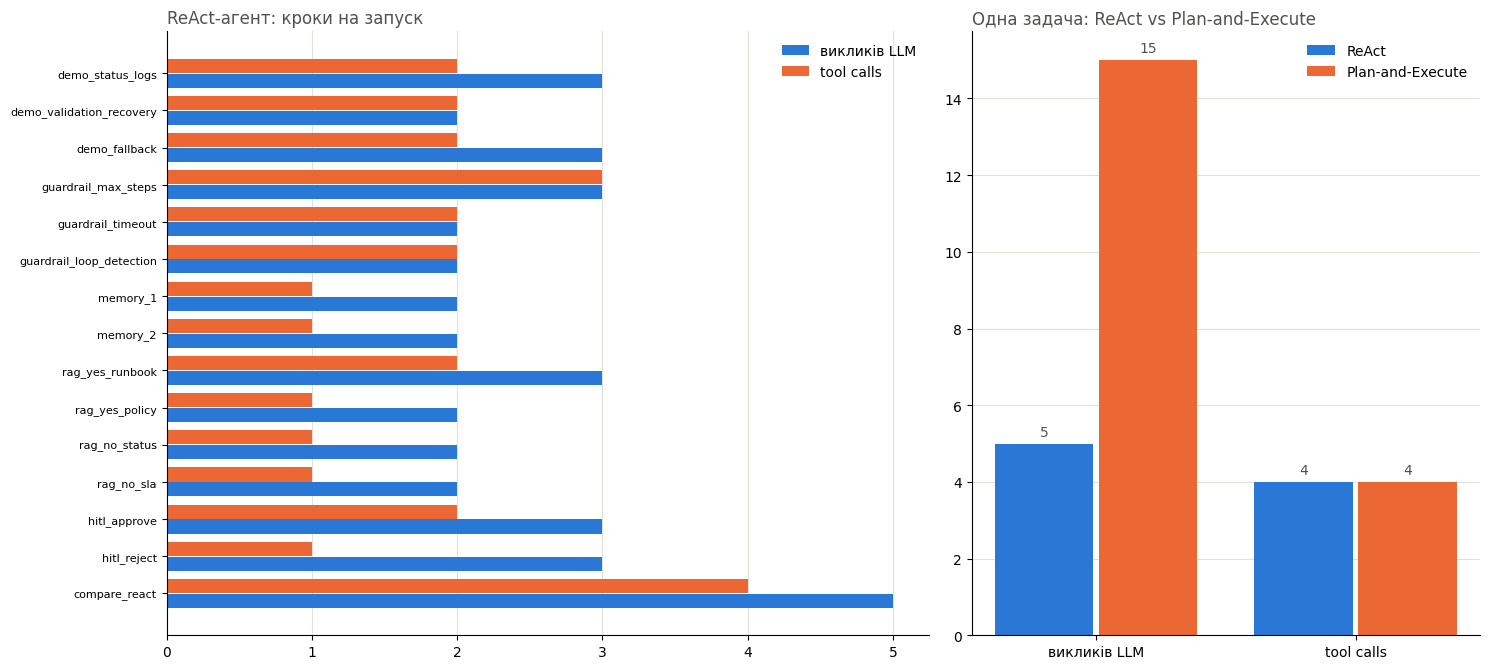

Запусків ReAct: 15, зупинено guardrails: 3, усього tool calls: 27


In [19]:
import matplotlib.pyplot as plt

BLUE, ORANGE, INK, GRID = "#2a78d6", "#eb6834", "#52514e", "#e1e0d9"
runs = [r for r in RUN_LOG if not r["tag"].startswith("test_")]
positions = range(len(runs))

fig, (left, right) = plt.subplots(1, 2, figsize=(15, 0.32 * len(runs) + 2), gridspec_kw={"width_ratios": [3, 2]})
left.barh([p + 0.2 for p in positions], [r["steps"] for r in runs], height=0.38, color=BLUE, label="викликів LLM")
left.barh([p - 0.2 for p in positions], [len(r["tool_calls"]) for r in runs], height=0.38, color=ORANGE, label="tool calls")
left.set_yticks(list(positions), [r["tag"] for r in runs], fontsize=8)
left.invert_yaxis()
left.set_title("ReAct-агент: кроки на запуск", loc="left", color=INK)
left.legend(frameon=False)

metrics = ["викликів LLM", "tool calls"]
react_values = [react_cmp["steps"], len(react_cmp["tool_calls"])]
plan_values = [plan_cmp["llm_calls"], len(plan_cmp["tool_calls"])]
x = range(len(metrics))
right.bar([i - 0.2 for i in x], react_values, width=0.38, color=BLUE, label="ReAct")
right.bar([i + 0.2 for i in x], plan_values, width=0.38, color=ORANGE, label="Plan-and-Execute")
for i, (a, b) in enumerate(zip(react_values, plan_values)):
    right.text(i - 0.2, a + 0.2, str(a), ha="center", color=INK)
    right.text(i + 0.2, b + 0.2, str(b), ha="center", color=INK)
right.set_xticks(list(x), metrics)
right.set_title("Одна задача: ReAct vs Plan-and-Execute", loc="left", color=INK)
right.legend(frameon=False)

for ax in (left, right):
    ax.grid(axis="x" if ax is left else "y", color=GRID)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "agent_results.png", dpi=120)
plt.show()

print(f"Запусків ReAct: {len(runs)}, зупинено guardrails: {sum(r['halted'] for r in runs)}, "
      f"усього tool calls: {sum(len(r['tool_calls']) for r in runs)}")

## Секція 13. Тести pytest
Файл `test_incident_agent.py`: 9 тестів Pydantic-схем (коректні/некоректні входи), 7 тестів інструментів
(JSON-формат, RAG, fallback, ризиковий інструмент) та 3 тести ReAct-циклу (успішний прохід, детекція
повторів, max_steps). Локально тести імпортують модуль `incident_agent.py`, у Colab — об'єкти з ноутбука.
Вивід зберігається у `pytest_output.txt`, скриншот — у `pytest_results.png`.

============================= test session starts ==============================
platform darwin -- Python 3.11.8, pytest-9.1.1, pluggy-1.6.0 -- /Users/svitlanamoiseyenko/.pyenv/versions/3.11.8/bin/python3.11
rootdir: /Users/svitlanamoiseyenko/Repos/GOIT/autonomous_agent_design/hm-03
plugins: anyio-4.4.0, langsmith-0.8.9
collecting ... collected 19 items

test_incident_agent.py::test_service_status_args_normalizes_service PASSED [  5%]
test_incident_agent.py::test_query_logs_args_defaults_and_level_normalization PASSED [ 10%]
test_incident_agent.py::test_calculate_sla_args_valid PASSED             [ 15%]
test_incident_agent.py::test_restart_args_valid PASSED                   [ 21%]
test_incident_agent.py::test_service_status_args_unknown_service PASSED  [ 26%]
test_incident_agent.py::test_query_logs_args_invalid_level_and_window PASSED [ 31%]
test_incident_agent.py::test_calculate_sla_args_downtime_exceeds_period PASSED [ 36%]
test_incident_agent.py::test_restart_args_protected_servic

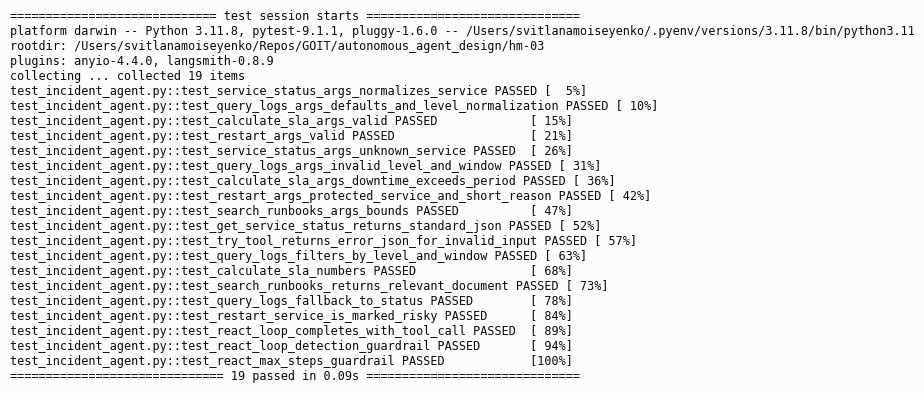

In [20]:
import io
from contextlib import redirect_stdout

import matplotlib.pyplot as plt
import pytest

TEST_SOURCE = r'''
"""Тести SRE-асистента: Pydantic-схеми, інструменти, ReAct-цикл."""
import json

import pytest
from pydantic import ValidationError

try:
    import incident_agent as A          # локальний запуск: pytest -v
except ImportError:                     # запуск із ноутбука (Colab): об'єкти вже в __main__
    import __main__ as A


# ---------- Pydantic-схеми: коректні входи ----------
def test_service_status_args_normalizes_service():
    assert A.ServiceStatusArgs(service="  Payments ").service == "payments"


def test_query_logs_args_defaults_and_level_normalization():
    args = A.QueryLogsArgs(service="api_gateway", level="error")
    assert (args.service, args.level, args.last_minutes) == ("api-gateway", "ERROR", 30)


def test_calculate_sla_args_valid():
    args = A.CalculateSlaArgs(service="payments", downtime_minutes=45, period_days=30)
    assert args.downtime_minutes == 45.0 and args.target_percent == 99.9


def test_restart_args_valid():
    args = A.RestartServiceArgs(service="payments", reason="Деградація сервісу після деплою v2.14.0")
    assert args.service == "payments"


# ---------- Pydantic-схеми: некоректні входи ----------
def test_service_status_args_unknown_service():
    with pytest.raises(ValidationError, match="Невідомий сервіс"):
        A.ServiceStatusArgs(service="billing")


def test_query_logs_args_invalid_level_and_window():
    with pytest.raises(ValidationError, match="Невідомий рівень"):
        A.QueryLogsArgs(service="payments", level="DEBUG")
    with pytest.raises(ValidationError):
        A.QueryLogsArgs(service="payments", last_minutes=0)


def test_calculate_sla_args_downtime_exceeds_period():
    with pytest.raises(ValidationError, match="перевищує тривалість періоду"):
        A.CalculateSlaArgs(service="payments", downtime_minutes=5000, period_days=1)


def test_restart_args_protected_service_and_short_reason():
    with pytest.raises(ValidationError, match="заборонено політикою"):
        A.RestartServiceArgs(service="postgres-db", reason="повільні запити у базі")
    with pytest.raises(ValidationError, match="щонайменше 10 символів"):
        A.RestartServiceArgs(service="payments", reason="коротко")


def test_search_runbooks_args_bounds():
    with pytest.raises(ValidationError):
        A.SearchRunbooksArgs(query="ab")
    with pytest.raises(ValidationError):
        A.SearchRunbooksArgs(query="політика SLA", top_k=9)


# ---------- Інструменти ----------
def test_get_service_status_returns_standard_json():
    payload = json.loads(A.get_service_status.invoke({"service": "payments"}))
    assert payload["status"] == "ok"
    assert payload["data"]["service"] == "payments" and payload["data"]["status"] == "degraded"


def test_try_tool_returns_error_json_for_invalid_input():
    payload = json.loads(A.try_tool("get_service_status", {"service": "billing"}))
    assert payload["status"] == "error" and "Невідомий сервіс" in payload["error"]


def test_query_logs_filters_by_level_and_window():
    payload = json.loads(A.query_logs.invoke({"service": "payments", "level": "ERROR", "last_minutes": 10}))
    assert payload["data"]["count"] == 2
    assert all(e["level"] == "ERROR" for e in payload["data"]["entries"])


def test_calculate_sla_numbers():
    data = json.loads(A.calculate_sla.invoke({"service": "payments", "downtime_minutes": 45, "period_days": 30}))["data"]
    assert data["error_budget_minutes"] == pytest.approx(43.2)
    assert data["sla_breached"] is True
    assert data["availability_percent"] == pytest.approx(99.8958, abs=1e-3)


def test_search_runbooks_returns_relevant_document():
    data = json.loads(A.search_runbooks.invoke({"query": "політика перезапуску сервісів підтвердження людини", "top_k": 2}))["data"]
    assert len(data["documents"]) == 2
    assert data["documents"][0]["doc_id"] == "restart_policy"


def test_query_logs_fallback_to_status():
    result, used = A.try_tool_with_fallback("query_logs", {"service": "notifications"})
    payload = json.loads(result)
    assert used == "get_service_status"
    assert payload["status"] == "error" and payload["fallback"]["result"]["data"]["status"] == "down"


def test_restart_service_is_marked_risky():
    assert "restart_service" in A.RISKY_TOOLS
    data = json.loads(A.restart_service.invoke({"service": "auth-service", "reason": "Тестовий перезапуск stateless-сервісу"}))["data"]
    assert data["status"] == "restarting" and len(data["restart_id"]) == 8


# ---------- ReAct-цикл ----------
def test_react_loop_completes_with_tool_call():
    record = A.run_agent("Перевір статус сервісу payments.", llm=A.ScriptedSreLLM(), tag="test_react")
    assert not record["halted"]
    assert [c["tool"] for c in record["tool_calls"]] == ["get_service_status"]
    assert "degraded" in record["final"]
    assert [e["type"] for e in record["trajectory"]] == ["thought", "observation", "thought", "final_answer"]


def test_react_loop_detection_guardrail():
    record = A.run_agent("Перевір зациклення: питай статус api-gateway знову і знову.",
                         llm=A.ScriptedSreLLM(), config=A.AgentConfig(max_steps=10), tag="test_loop")
    assert record["halted"] and record["halt_reason"].startswith("loop")
    assert record["steps"] == 2


def test_react_max_steps_guardrail():
    record = A.run_agent("Порахуй довгий ланцюг SLA крок за кроком.",
                         llm=A.ScriptedSreLLM(), config=A.AgentConfig(max_steps=3), tag="test_max_steps")
    assert record["halted"] and record["halt_reason"].startswith("max_steps")
    assert record["steps"] == 3
'''

TEST_PATH = OUTPUT_DIR / "test_incident_agent.py"
TEST_PATH.write_text(TEST_SOURCE.lstrip(), encoding="utf-8")

buffer = io.StringIO()
with redirect_stdout(buffer):
    exit_code = pytest.main(["-v", "-p", "no:cacheprovider", "--color=no", "-W", "ignore", str(TEST_PATH)])
pytest_output = buffer.getvalue()
print(pytest_output)
print(f"pytest exit code: {exit_code} ({'усі тести пройдено' if exit_code == 0 else 'є помилки'})")
(OUTPUT_DIR / "pytest_output.txt").write_text(pytest_output, encoding="utf-8")

# «Скриншот» результатів pytest: текстовий вивід рендериться у PNG.
lines = [line for line in pytest_output.splitlines() if line.strip()]
fig, ax = plt.subplots(figsize=(11, 0.17 * len(lines) + 0.4))
ax.axis("off")
ax.text(0, 1, "\n".join(lines), family="monospace", fontsize=8.5, va="top", ha="left", color="#0b0b0b",
        transform=ax.transAxes)
fig.patch.set_facecolor("#fcfcfb")
fig.savefig(OUTPUT_DIR / "pytest_results.png", dpi=130, bbox_inches="tight")
plt.show()

# Закриваємо з'єднання checkpointer-ів: WAL-журнал зливається у checkpoints.sqlite.
main_conn.close()
restored_conn.close()

## Секція 14. Висновки та аналіз

### Що реалізовано
| Вимога | Реалізація |
|---|---|
| 3–5 інструментів з Pydantic v2 | 5 інструментів, кожен із `BaseModel` + `Field` + `field_validator`; вихід `{status, data/error}` |
| ReAct-агент із guardrails | граф `agent → tools/risky_tools → agent → finalize`; `max_steps=10`, `timeout=120 с`, детекція повторів; JSON-лог `trajectory.json` |
| Plan-and-Execute | `planner → executor (вкладений ReAct) → replanner`; `with_structured_output(Plan / ReplanDecision)`; демо `revise` |
| Checkpointer | `SqliteSaver` поверх файлу; пам'ять між запитами у thread-і; відновлення після «збою»; `get_state()` + `get_state_history()` |
| Agentic RAG | ChromaDB, 10 документів; агент викликає `search_runbooks` лише для питань «що робити / політика» |
| Human-in-the-Loop | `interrupt_before=["risky_tools"]`; approve через `invoke(None)`, reject через `update_state(as_node=...)` |
| Тести | 19 тестів pytest: схеми (9), інструменти (7), ReAct-цикл (3) |
| Бонуси | порівняння ReAct vs Plan-and-Execute; Mermaid-візуалізація обох графів; fallback-стратегія `query_logs → get_service_status` |

### Спостереження
* **ReAct** економніший на коротких задачах: усі незалежні виклики виконуються за один хід, а рішення
  про наступний крок ухвалюється одразу після спостереження.
* **Plan-and-Execute** робить більше викликів LLM (планувальник + replanner після кожного кроку), але
  дає явний контроль: план видно заздалегідь, а помилка виконання призводить до осмисленого `revise`,
  а не до «тихої» зміни поведінки.
* **Checkpointer** перетворює агента на відновлювану систему: стан живе у файлі, а не в пам'яті процесу,
  тож пауза перед ризиковою дією може тривати хоч добу.
* **HITL через `interrupt_before`** не потребує змін у логіці вузлів: контроль ризикових дій —
  властивість графа, а не промпту.
* **Обмеження офлайн-фолбека:** рішення `ScriptedSreLLM` детерміновані й правилові; з реальною LLM
  (`OPENAI_API_KEY`) агент міркує вільно, а всі guardrails, checkpointing і HITL працюють без змін.